# Tutorial 04 — Packing and a Small Mutation Scan

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/04_packing_and_mutation_scan.ipynb)

This tutorial repacks side chains in a small ubiquitin structure, inspects rotamer candidates, and composes example mutation-scan and design workflows.

## Learning objectives

- Build a repacking task and choose movable blocks.
- Run the packer and inspect sequence and coordinates.
- Distinguish repacking from design and examine sampling variability.

## Before you begin

- **Prerequisites:** [03 — Scoring and analysis](03_scoring_and_analysis.ipynb), including weighted scores and block-pair accounting.
- **Curriculum:** This is the discrete-sampling branch after 03. Complete the parallel [05 — Minimization](05_minimization_constraints_kinematics.ipynb) branch before [06 — FastRelax](06_fast_relax.ipynb) combines both.
- **Related:** [Packing workflow](../workflows/packing.md) · [Packing API](../api/pack.rst)

Repacking preserves residue identity; design allows selected identities to change. The mutation scan is an example built from lower-level APIs, not a built-in TMol protocol. CPU and GPU packers can select different outcomes.

## Setup

The setup uses the sampler construction exercised by TMol's packer tests and existing score/pack/minimize tutorial. The ten-residue slice keeps CPU execution and two-outcome comparisons practical. NumPy and PyTorch seeds are initialized, but the current CPU annealer uses the C `rand()` stream and is not controlled by `torch.manual_seed()`. Hydrogen coordinates are optimized during pose construction before scores are interpreted.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol.database import ParameterDatabase
from tmol.io import pose_stack_from_biotite
from tmol.numeric import coord_dihedrals
from tmol.ops import (
    build_sidechain_coord_mask,
    compute_block_adjacency,
    compute_block_centroids_and_furthest_dist,
    res_mask_to_coord_mask,
)
from tmol.pack import PackerPalette, PackerTask, SetPackerTask, pack_rotamers
from tmol.pack.rotamer import FixedAAChiSampler, IncludeCurrentSampler, build_rotamers
from tmol.pack.rotamer.dunbrack import create_dunbrack_sampler_from_database
from tmol.pose import PoseStackBuilder
from tmol.score import beta2016_score_function

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
warnings.filterwarnings(
    "ignore", message=r"Sparse invariant checks are implicitly disabled.*"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol/tests/data/cif/1UBQ.cif"

param_db = ParameterDatabase.get_default()
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 10)]
pose_diagnostics = StringIO()
try:
    with redirect_stdout(pose_diagnostics), redirect_stderr(pose_diagnostics):
        # Optimize hydrogen coordinates before comparing interpreted scores.
        pose_stack = pose_stack_from_biotite(
            protein_slice, device, param_db=param_db, no_optH=False
        )
except Exception:
    print(pose_diagnostics.getvalue())
    raise
score_function = beta2016_score_function(device, param_db=param_db)


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        display(frame)
        return None
    return show(frame)


def total_score(pose):
    scorer = score_function.render_whole_pose_scoring_module(pose)
    return float(scorer(pose.coords).detach().cpu()[0])

print(f"device={device}; input={cif_path.name}; slice blocks={pose_stack.max_n_blocks}")

device=cpu; input=1UBQ.cif; slice blocks=10


## Fixed-sequence regional repacking

`PackerPalette` defines the residue-type space considered from each starting block. `PackerTask.restrict_to_repacking()` keeps each position's `name3` fixed. The task then uses Dunbrack rotamers, fixed-amino-acid chi samples, and the current conformation.

Here residues 3–8 (zero-based block indices 2–7) are allowed to repack. `disable_packing_by_block_mask()` receives `True` where packing should be disabled.

In [3]:
palette = PackerPalette()
repack_task = PackerTask(pose_stack, palette)
repack_task.restrict_to_repacking()

packing_region = torch.zeros(
    (pose_stack.n_poses, pose_stack.max_n_blocks),
    dtype=torch.bool,
    device=device,
)
packing_region[:, 2:8] = True
repack_task.disable_packing_by_block_mask(~packing_region)
repack_task.add_conformer_sampler(
    create_dunbrack_sampler_from_database(param_db, device)
)
repack_task.add_conformer_sampler(FixedAAChiSampler())
repack_task.add_conformer_sampler(IncludeCurrentSampler())

start_score = total_score(pose_stack)
torch.manual_seed(SEED)
repacked_pose = pack_rotamers(pose_stack, score_function, repack_task)
repacked_score = total_score(repacked_pose)

packing_atom_mask = res_mask_to_coord_mask(pose_stack, packing_region)
packing_sidechain_mask = packing_atom_mask & build_sidechain_coord_mask(pose_stack)
sidechain_displacement = torch.linalg.vector_norm(
    repacked_pose.coords - pose_stack.coords, dim=-1
)[packing_sidechain_mask]
sidechain_rms_displacement = float(
    torch.sqrt(torch.mean(sidechain_displacement.square())).detach().cpu()
)
max_sidechain_displacement = float(sidechain_displacement.max().detach().cpu())
changed_sidechain_atoms = int((sidechain_displacement > 1e-3).sum().detach().cpu())

repack_frame = pd.DataFrame(
    [
        {
            "stage": "input",
            "beta2016": start_score,
            "score_change": 0.0,
            "packed_sidechain_RMS_displacement_A": 0.0,
            "max_sidechain_displacement_A": 0.0,
            "changed_sidechain_atoms": 0,
        },
        {
            "stage": "regional repack",
            "beta2016": repacked_score,
            "score_change": repacked_score - start_score,
            "packed_sidechain_RMS_displacement_A": sidechain_rms_displacement,
            "max_sidechain_displacement_A": max_sidechain_displacement,
            "changed_sidechain_atoms": changed_sidechain_atoms,
        },
    ]
)
show_table(repack_frame)

**Expected observations.** The amino-acid sequence is unchanged, only blocks 3–8 are allowed to choose side-chain conformers, and the score may decrease when the input side chains are suboptimal. The interactive table quantifies score change, RMS and maximum displacement over packed side-chain atoms, and how many moved more than 0.001 Å. Backbone movement should remain zero because the packer chooses discrete side-chain conformers rather than minimizing coordinates.

**CPU and GPU annealers are different algorithms.** The current CPU implementation runs one trajectory with 20 outer cycles, using `5 × N_rotamers` uniformly sampled random trials per cycle (about five trials per rotamer on average) and a final quench. It draws from C `rand()`, so `torch.manual_seed()` does not control CPU packing. The current CUDA implementation starts 500 high-temperature trajectories, expands selected results into 1,250 low-temperature trajectories, and sends 312 onward to full quenching; it draws from PyTorch's CUDA Philox generator, so the PyTorch CUDA seed controls that random stream. Packing remains stochastic, and CPU and GPU results should be treated as separate search protocols rather than expected to reproduce one another.

The viewer is interactive when the parent documentation environment provides `py3Dmol`.

In [4]:
try:
    display(
        tmol.switchable_view(
            {"input": pose_stack, "regional repack": repacked_pose},
            notes={
                "input": f"weighted score: {start_score:.3f}",
                "regional repack": (
                    f"score {repacked_score:.3f}; Δ {repacked_score - start_score:+.3f}; "
                    f"side-chain RMS motion {sidechain_rms_displacement:.3f} Å"
                ),
            },
            width=720,
            height=420,
        )
    )
except ImportError as exc:
    print("Interactive repacking comparison unavailable:", exc)

## Expand side-chain sampling

TMol's `PackerTask.or_expand_chi()` requests additional samples at approximately ±1 standard deviation around supported chi wells. TMol chi indices are zero-based: index `0` is χ1 and index `1` is χ2. This is the closest local sampling concept to Rosetta's `ex1` and `ex2` task options, but it does not imply protocol or candidate-set equivalence.

Two separate questions are kept separate below. Building rotamers gives deterministic candidate counts and geometry for a fixed pose/task. Packing those candidates gives stochastic score outcomes. Extra sampling enlarges the search but does not guarantee a lower selected score. The CUDA path shows two seeded outcomes per setting; the CPU path shows one outcome because `torch.manual_seed()` does not seed its C RNG. Neither is a convergence study. `IncludeCurrentSampler` keeps the input conformation available.

In [5]:
expanded_task = PackerTask(pose_stack, palette)
expanded_task.restrict_to_repacking()
expanded_task.disable_packing_by_block_mask(~packing_region)
expanded_task.add_conformer_sampler(
    create_dunbrack_sampler_from_database(param_db, device)
)
expanded_task.add_conformer_sampler(FixedAAChiSampler())
expanded_task.add_conformer_sampler(IncludeCurrentSampler())
# Zero-based chi indices 0 and 1 map conceptually to Rosetta ex1 and ex2.
expanded_task.or_expand_chi(0)
expanded_task.or_expand_chi(1)

torch.manual_seed(SEED)
expanded_repacked_pose = pack_rotamers(
    pose_stack, score_function, expanded_task
)
expanded_score = total_score(expanded_repacked_pose)

# Keep this deliberately small. CUDA gets a second seeded outcome because
# torch.manual_seed() controls its Philox stream; the CPU C RNG has no exposed
# seed API, so repeating under a different torch seed would not be a controlled
# replicate.
sampling_outcome_rows = [
    {
        "sampling": "standard",
        "outcome": 1,
        "weighted_score_units": repacked_score,
    },
    {
        "sampling": "expanded χ1 + χ2",
        "outcome": 1,
        "weighted_score_units": expanded_score,
    },
]
if device.type == "cuda":
    torch.manual_seed(SEED + 1)
    standard_repeat_pose = pack_rotamers(pose_stack, score_function, repack_task)
    torch.manual_seed(SEED + 1001)
    expanded_repeat_pose = pack_rotamers(pose_stack, score_function, expanded_task)
    sampling_outcome_rows.extend(
        [
            {
                "sampling": "standard",
                "outcome": 2,
                "weighted_score_units": total_score(standard_repeat_pose),
            },
            {
                "sampling": "expanded χ1 + χ2",
                "outcome": 2,
                "weighted_score_units": total_score(expanded_repeat_pose),
            },
        ]
    )
else:
    print("CPU packing shown once per setting: torch seeds do not control C rand().")
sampling_outcome_frame = pd.DataFrame(sampling_outcome_rows)
show_table(sampling_outcome_frame)
sampling_outcome_summary = (
    sampling_outcome_frame.groupby("sampling", as_index=False)
    .agg(
        score_mean=("weighted_score_units", "mean"),
        score_min=("weighted_score_units", "min"),
        score_max=("weighted_score_units", "max"),
    )
)
sampling_outcome_summary["observed_range"] = (
    sampling_outcome_summary["score_max"]
    - sampling_outcome_summary["score_min"]
)
show_table(sampling_outcome_summary)
try:
    display(
        tmol.switchable_view(
            {
                "standard rotamers": repacked_pose,
                "expanded χ1 + χ2": expanded_repacked_pose,
            },
            notes={
                "standard rotamers": f"outcome 1 weighted score {repacked_score:.3f}",
                "expanded χ1 + χ2": f"outcome 1 weighted score {expanded_score:.3f}",
            },
        )
    )
except ImportError as exc:
    print("Interactive sampling comparison unavailable:", exc)

CPU packing shown once per setting: torch seeds do not control C rand().


## Inspect deterministic candidate expansion

Expanded chi sampling changes the discrete search space before annealing. The table below builds both rotamer sets explicitly and reports deterministic candidate counts at each packed position. A wrapped χ1-versus-χ2 plot then shows candidate geometry for one representative block without treating internal rotamer storage order as a physical coordinate.

These torsions describe the candidate set, not a trajectory or score result: simulated annealing evaluates assignments stochastically and returns only the selected final conformation.

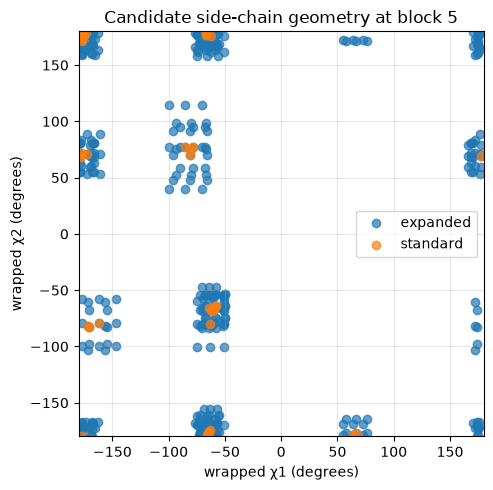

In [6]:
standard_rotamer_pose, standard_rotamers = build_rotamers(
    pose_stack,
    SetPackerTask.from_packer_task(repack_task),
    pose_stack.packed_block_types.chem_db,
)
expanded_rotamer_pose, expanded_rotamers = build_rotamers(
    pose_stack,
    SetPackerTask.from_packer_task(expanded_task),
    pose_stack.packed_block_types.chem_db,
)

rotamer_count_rows = []
for block_index in range(2, 8):
    block_type = pose_stack.block_type(0, block_index)
    rotamer_count_rows.append(
        {
            "block_index": block_index,
            "residue": block_type.name3,
            "standard_candidates": int(
                standard_rotamers.n_rots_for_block[0, block_index]
            ),
            "expanded_candidates": int(
                expanded_rotamers.n_rots_for_block[0, block_index]
            ),
        }
    )
rotamer_count_frame = pd.DataFrame(rotamer_count_rows)
rotamer_count_frame["additional_candidates"] = (
    rotamer_count_frame["expanded_candidates"]
    - rotamer_count_frame["standard_candidates"]
)
show_table(rotamer_count_frame)


def named_chi_frame(label, rotamer_pose, rotamer_set, block_index):
    rows = []
    n_rotamers = int(rotamer_set.n_rots_for_block[0, block_index])
    rotamer_offset = int(rotamer_set.rot_offset_for_block[0, block_index])
    for local_rotamer in range(n_rotamers):
        rotamer_index = rotamer_offset + local_rotamer
        block_type_index = int(rotamer_set.block_type_ind_for_rot[rotamer_index])
        block_type = rotamer_pose.packed_block_types.active_block_types[
            block_type_index
        ]
        coordinate_offset = int(rotamer_set.coord_offset_for_rot[rotamer_index])
        row = {"sampling": label, "rotamer": local_rotamer}
        for torsion_index in block_type.sc_torsions:
            atom_indices = block_type.ordered_torsions[torsion_index, :, 0]
            if np.any(atom_indices < 0):
                continue
            coordinates = rotamer_set.coords[
                coordinate_offset
                + torch.as_tensor(atom_indices, dtype=torch.long, device=device)
            ].double()
            radians = coord_dihedrals(
                coordinates[0:1],
                coordinates[1:2],
                coordinates[2:3],
                coordinates[3:4],
            )[0]
            torsion_name = block_type.torsions[torsion_index].name
            row[f"{torsion_name}_degrees"] = float(torch.rad2deg(radians).cpu())
        rows.append(row)
    return pd.DataFrame(rows)


# Block 5 is LYS in this 1UBQ slice and therefore demonstrates both chi1 and chi2.
rotamer_inspection_block = 5
rotamer_geometry_frame = pd.concat(
    [
        named_chi_frame(
            "standard",
            standard_rotamer_pose,
            standard_rotamers,
            rotamer_inspection_block,
        ),
        named_chi_frame(
            "expanded",
            expanded_rotamer_pose,
            expanded_rotamers,
            rotamer_inspection_block,
        ),
    ],
    ignore_index=True,
)
show_table(rotamer_geometry_frame)

chi1_column = next(
    (
        column
        for column in rotamer_geometry_frame.columns
        if column.lower().startswith("chi1") and column.endswith("_degrees")
    ),
    None,
)
chi2_column = next(
    (
        column
        for column in rotamer_geometry_frame.columns
        if column.lower().startswith("chi2") and column.endswith("_degrees")
    ),
    None,
)
if chi1_column is not None and chi2_column is not None:
    wrapped_geometry = rotamer_geometry_frame.copy()
    wrapped_geometry["chi1_wrapped_degrees"] = (
        (wrapped_geometry[chi1_column] + 180.0) % 360.0 - 180.0
    )
    wrapped_geometry["chi2_wrapped_degrees"] = (
        (wrapped_geometry[chi2_column] + 180.0) % 360.0 - 180.0
    )
    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    for label, values in wrapped_geometry.groupby("sampling"):
        ax.scatter(
            values["chi1_wrapped_degrees"],
            values["chi2_wrapped_degrees"],
            label=label,
            alpha=0.7,
        )
    ax.set(
        xlim=(-180, 180),
        ylim=(-180, 180),
        xlabel="wrapped χ1 (degrees)",
        ylabel="wrapped χ2 (degrees)",
        title=f"Candidate side-chain geometry at block {rotamer_inspection_block}",
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Deliberately small local-shell mutation scan

> **Inspected helper, not a built-in protocol.** `PackerTask` currently has no public method that restricts one position to one amino-acid identity. The helper below only turns `per_block_is_block_type_allowed` entries from `True` to `False`, preserving the task's monotonic-mask contract. Its field use was inspected against `tmol/pack/packer_task.py` and packer tests.

Every non-target position is restricted to its original block type. At the target, only considered block types with the requested `name3` remain. Repacking is additionally restricted to the target plus blocks selected by `compute_block_adjacency()`: centroid distance less than the sum of both furthest-atom radii plus the helper's default 5 Å constant. This adapts the local-neighborhood experimental design used by Rosetta TaskOperations without claiming a `NeighborhoodResidueSelector` API in TMol.

The scan uses two jointly batched stochastic outcomes per identity. Identity distributions are summarized independently; differences are computed between their means, never by arbitrarily pairing WT and mutant outcomes. Two outcomes are enough to illustrate the analysis but not convergence, and observed spread may be exactly zero—particularly for a small CPU run. The WT row is a **repacked WT**, and every reported difference is a score-function delta, not a ΔΔG.

In [7]:
def restrict_batched_substitutions(task, block_index, name3_by_pose):
    """Keep the original sequence except for one requested identity per pose."""
    if len(name3_by_pose) != task.per_block_is_block_type_allowed.shape[0]:
        raise ValueError("Provide exactly one requested identity per pose")
    considered = task.per_block_considered_block_types
    keep = task.per_block_considered_block_types_is_orig.detach().clone()
    for pose_index, name3 in enumerate(name3_by_pose):
        target_considered = (
            considered[pose_index, block_index].detach().cpu().tolist()
        )
        target_keep = torch.tensor(
            [
                index >= 0 and task.pbt.active_block_types[index].name3 == name3
                for index in target_considered
            ],
            dtype=torch.bool,
            device=task.device,
        )
        if not torch.any(target_keep):
            raise ValueError(f"{name3!r} is not considered at block {block_index}")
        keep[pose_index, block_index] = target_keep
    task.per_block_is_block_type_allowed = torch.logical_and(
        task.per_block_is_block_type_allowed, keep
    )
    return task


def add_standard_samplers(task):
    task.add_conformer_sampler(
        create_dunbrack_sampler_from_database(param_db, device)
    )
    task.add_conformer_sampler(FixedAAChiSampler())
    task.add_conformer_sampler(IncludeCurrentSampler())
    return task

In [8]:
target_block = 4
original_type_index = int(pose_stack.block_type_ind64[0, target_block].item())
original_name3 = pose_stack.packed_block_types.active_block_types[
    original_type_index
].name3
variants = list(dict.fromkeys([original_name3, "ALA", "LEU", "PHE"]))
target_label = (
    f"{pose_stack.pdb_info.chain_labels[0, target_block]}:"
    f"{pose_stack.pdb_info.residue_labels[0, target_block]}"
    f"{pose_stack.pdb_info.residue_insertion_codes[0, target_block]}"
)

# Build one explicit local shell with the existing score_utils geometry helpers.
block_centroids, block_radii = compute_block_centroids_and_furthest_dist(pose_stack)
block_adjacency = compute_block_adjacency(block_centroids, block_radii)
mutation_shell = block_adjacency[:, target_block].clone()
mutation_shell[:, target_block] = True
shell_block_indices = torch.nonzero(mutation_shell[0], as_tuple=False).flatten().tolist()
shell_labels = [
    f"{pose_stack.pdb_info.chain_labels[0, block]}:"
    f"{pose_stack.pdb_info.residue_labels[0, block]}"
    f"{pose_stack.pdb_info.residue_insertion_codes[0, block]}"
    for block in shell_block_indices
]
print(
    f"mutation target block {target_block} ({target_label}); local repacking shell "
    f"has {len(shell_block_indices)} blocks: {', '.join(shell_labels)}"
)


def target_to_rest_score(pose, block_index):
    scorer = score_function.render_block_pair_scoring_module(pose)
    matrix = scorer(pose.coords, sum_terms=True, apply_weights=True)[0]
    partners = torch.ones(matrix.shape[0], dtype=torch.bool, device=matrix.device)
    partners[block_index] = False
    return float(
        (matrix[block_index, partners].sum() + matrix[partners, block_index].sum())
        .detach()
        .cpu()
    )


# CUDA uses two seeded outcomes per identity. On CPU, show one batch member
# per identity because torch.manual_seed() does not control the C RNG.
n_scan_outcomes = 2 if device.type == "cuda" else 1
scan_requests = [
    (outcome, variant)
    for outcome in range(1, n_scan_outcomes + 1)
    for variant in variants
]
requested_variants = [variant for _, variant in scan_requests]
mutation_batch = PoseStackBuilder.from_poses(
    [pose_stack] * len(scan_requests), device
)
mutation_scan_task = PackerTask(mutation_batch, PackerPalette())
restrict_batched_substitutions(
    mutation_scan_task, target_block, requested_variants
)
mutation_shell_batch = mutation_shell.expand(len(scan_requests), -1).clone()
mutation_scan_task.disable_packing_by_block_mask(~mutation_shell_batch)
add_standard_samplers(mutation_scan_task)

torch.manual_seed(SEED)  # Controls CUDA annealing, not the CPU C rand() stream.
if device.type == "cuda":
    torch.cuda.synchronize()
scan_start = perf_counter()
packed_mutation_batch = pack_rotamers(
    mutation_batch, score_function, mutation_scan_task
)
if device.type == "cuda":
    torch.cuda.synchronize()
scan_seconds = perf_counter() - scan_start

scan_rows = []
variant_poses = {}
for pose_index, (outcome, variant) in enumerate(scan_requests):
    packed_variant = packed_mutation_batch.split(pose_index)
    state_label = f"{variant} (repacked WT)" if variant == original_name3 else variant
    if outcome == 1:
        variant_poses[state_label] = packed_variant

    # The monotonic identity helper must leave every non-target identity unchanged.
    for block_index in range(packed_variant.max_n_blocks):
        if block_index != target_block:
            assert (
                packed_variant.block_type(0, block_index).name3
                == pose_stack.block_type(0, block_index).name3
            )

    scan_rows.append(
        {
            "block_index": target_block,
            "pdb_label": target_label,
            "variant": variant,
            "state": state_label,
            "outcome": outcome,
            "total_weighted_score_units": total_score(packed_variant),
            "target_to_rest_weighted_score_units": target_to_rest_score(
                packed_variant, target_block
            ),
            "shared_batch_seconds": scan_seconds,
        }
    )

scan_frame = pd.DataFrame(scan_rows)
show_table(scan_frame.sort_values(["variant", "outcome"]))

# Summarize each identity independently, then compare distribution means.
scan_summary = (
    scan_frame.groupby(["variant", "state"], as_index=False)
    .agg(
        total_score_mean=("total_weighted_score_units", "mean"),
        total_score_min=("total_weighted_score_units", "min"),
        total_score_max=("total_weighted_score_units", "max"),
        target_to_rest_mean=("target_to_rest_weighted_score_units", "mean"),
        target_to_rest_min=("target_to_rest_weighted_score_units", "min"),
        target_to_rest_max=("target_to_rest_weighted_score_units", "max"),
    )
)
scan_summary["total_score_range"] = (
    scan_summary["total_score_max"] - scan_summary["total_score_min"]
)
scan_summary["target_to_rest_range"] = (
    scan_summary["target_to_rest_max"] - scan_summary["target_to_rest_min"]
)
wt_summary = scan_summary.loc[scan_summary["variant"] == original_name3].iloc[0]
scan_summary["total_difference_of_means_vs_repacked_wt_non_ddg"] = (
    scan_summary["total_score_mean"] - wt_summary["total_score_mean"]
)
scan_summary["target_to_rest_difference_of_means_vs_repacked_wt_non_ddg"] = (
    scan_summary["target_to_rest_mean"] - wt_summary["target_to_rest_mean"]
)
scan_summary = scan_summary.sort_values(
    "total_difference_of_means_vs_repacked_wt_non_ddg"
)
show_table(scan_summary)

mutation target block 4 (A:5); local repacking shell has 7 blocks: A:2, A:3, A:4, A:5, A:6, A:7, A:8


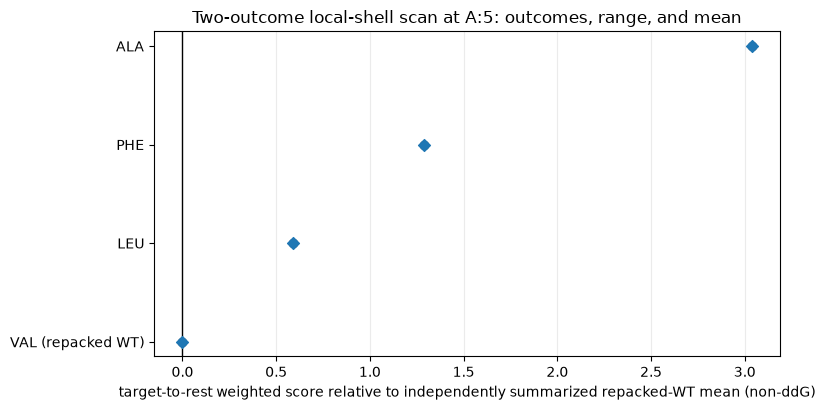

Orange: local repacking shell (7 blocks); mutation target: block 4 (A:5).


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [9]:
plot_summary = scan_summary.sort_values(
    "target_to_rest_difference_of_means_vs_repacked_wt_non_ddg"
).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 4.2))
for y_position, row in plot_summary.iterrows():
    outcome_offsets = (
        scan_frame.loc[
            scan_frame["variant"] == row["variant"],
            "target_to_rest_weighted_score_units",
        ].to_numpy()
        - wt_summary["target_to_rest_mean"]
    )
    ax.hlines(
        y_position,
        outcome_offsets.min(),
        outcome_offsets.max(),
        color="0.45",
        linewidth=2,
    )
    ax.scatter(outcome_offsets, np.full_like(outcome_offsets, y_position), color="0.35")
    ax.scatter(
        row["target_to_rest_difference_of_means_vs_repacked_wt_non_ddg"],
        y_position,
        color="tab:blue",
        marker="D",
        zorder=3,
    )
ax.axvline(0.0, color="black", linewidth=1)
ax.set_yticks(np.arange(len(plot_summary)), plot_summary["state"])
ax.set(
    xlabel=(
        "target-to-rest weighted score relative to independently summarized "
        "repacked-WT mean (non-ddG)"
    ),
    title=f"Two-outcome local-shell scan at {target_label}: outcomes, range, and mean",
)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

shell_atom_mask = res_mask_to_coord_mask(pose_stack, mutation_shell)
try:
    shell_viewer = tmol.view(
        pose_stack,
        highlighted=shell_atom_mask[pose_stack.real_atoms],
        highlight_color="#ff7f0e",
    )
    print(
        f"Orange: local repacking shell ({len(shell_block_indices)} blocks); "
        f"mutation target: block {target_block} ({target_label})."
    )
    shell_viewer.show()
except ImportError as exc:
    print("Interactive local-shell viewer unavailable:", exc)

**Expected observations.** Variants can differ in both total score and target-to-rest score. CUDA outcomes may show annealing spread, but an observed range of exactly zero is valid and does not establish determinism or convergence. The CPU path reports one result per identity rather than presenting torch-reseeded calls as controlled replicates. `shared_batch_seconds` is the wall time for the single packer call containing all identities and outcomes, not a per-variant time. The orange highlight identifies the complete geometry-defined repacking shell; the printed author label identifies the mutated block.

The WT distribution is an independently **repacked WT**, not the input structure and not an outcome-by-outcome partner for a mutant. Each identity's outcomes are summarized first. `target_to_rest_difference_of_means_vs_repacked_wt_non_ddg` then subtracts the independently summarized WT mean from the variant mean after both directed matrix orientations are combined; the total-score comparison uses the same difference-of-means rule. The plot centers outcomes on the WT mean, shows every observed point and range, and marks each mean with a diamond. Neither quantity is a ΔΔG: the workflow constructs no folded/unfolded, bound/unbound, or experimentally calibrated thermodynamic states. The one CPU result or two CUDA outcomes per identity are illustrative, not converged.

In [10]:
lowest_mean_state = scan_summary.iloc[0]
print(
    "lowest mean total score in this two-outcome local scan:",
    lowest_mean_state["state"],
    "(a stochastic score result, not a stability ranking)",
)
summary_by_state = scan_summary.set_index("state")
try:
    display(
        tmol.switchable_view(
            variant_poses,
            notes={
                state: (
                    f"outcome 1 structure; independently summarized mean score "
                    f"{summary_by_state.loc[state, 'total_score_mean']:.3f}; "
                    f"observed range "
                    f"{summary_by_state.loc[state, 'total_score_range']:.3f}"
                )
                for state in variant_poses
            },
            width=720,
            height=420,
        )
    )
except ImportError as exc:
    print("Interactive mutation comparison unavailable:", exc)

lowest mean total score in this two-outcome local scan: VAL (repacked WT) (a stochastic score result, not a stability ranking)


## Regional sequence design in a geometry-defined shell

A mutation scan fixes one identity per pose. Design instead permits several identities at several positions and lets simulated annealing choose combinations jointly with side-chain conformers. The design positions define a centroid/radius adjacency shell: design blocks may change identity, neighboring shell blocks are repack-only, and all blocks outside the shell are disabled. The code verifies those blocks remain fixed to float32 reconstruction precision using each block's own coordinate offset.

Here three batch members share one `PoseStack`; each pose receives its own complete packing call within the batch. On CUDA, each pose gets an independent Philox-driven full anneal (internally 500 high-temperature, 1,250 low-temperature, and 312 quench trajectories); the three poses are not three trajectories inside one annealer. On CPU, each pose uses the single-trajectory C-RNG implementation and batch members may collapse to identical results. The three members demonstrate the batched design API, not controlled CPU replicates, convergence, or identically searched replicates across devices.

This is a small demonstration of TMol's lower-level task masks, not an equivalent of Rosetta resfiles, HBNet, FastDesign, or backbone design.

In [11]:
def restrict_regional_design(task, allowed_name3_by_block):
    """Keep the original identity elsewhere and allow a small design alphabet."""
    considered = task.per_block_considered_block_types
    keep = task.per_block_considered_block_types_is_orig.detach().clone()
    for pose_index in range(keep.shape[0]):
        for block_index, allowed_names in allowed_name3_by_block.items():
            considered_types = (
                considered[pose_index, block_index].detach().cpu().tolist()
            )
            allowed = torch.tensor(
                [
                    index >= 0
                    and task.pbt.active_block_types[index].name3 in allowed_names
                    for index in considered_types
                ],
                dtype=torch.bool,
                device=task.device,
            )
            if not torch.any(allowed):
                raise ValueError(f"No requested identities at block {block_index}")
            keep[pose_index, block_index] = allowed
    task.per_block_is_block_type_allowed = torch.logical_and(
        task.per_block_is_block_type_allowed, keep
    )
    return task


design_blocks = [4, 6]
design_alphabet = {
    block_index: {
        pose_stack.block_type(0, block_index).name3,
        "ALA",
        "LEU",
        "PHE",
    }
    for block_index in design_blocks
}

# The union of adjacency neighborhoods defines which blocks may pack.
design_block_mask = torch.zeros(
    (pose_stack.n_poses, pose_stack.max_n_blocks),
    dtype=torch.bool,
    device=device,
)
design_block_mask[:, design_blocks] = True
design_shell = torch.any(block_adjacency[:, design_blocks, :], dim=1)
design_shell |= design_block_mask
design_repack_only = design_shell & ~design_block_mask
design_frozen = ~design_shell

def design_pdb_label(block_index):
    return (
        f"{pose_stack.pdb_info.chain_labels[0, block_index]}:"
        f"{pose_stack.pdb_info.residue_labels[0, block_index]}"
        f"{pose_stack.pdb_info.residue_insertion_codes[0, block_index]}"
    )


design_role_rows = []
for block_index in range(pose_stack.max_n_blocks):
    if bool(design_block_mask[0, block_index]):
        role = "design"
    elif bool(design_repack_only[0, block_index]):
        role = "repack-only"
    else:
        role = "frozen"
    design_role_rows.append(
        {
            "block_index": block_index,
            "pdb_label": design_pdb_label(block_index),
            "starting_identity": pose_stack.block_type(0, block_index).name3,
            "role": role,
        }
    )
design_role_frame = pd.DataFrame(design_role_rows)
show_table(design_role_frame)

n_design_batch_members = 3
design_batch = PoseStackBuilder.from_poses(
    [pose_stack] * n_design_batch_members, device
)
design_task = PackerTask(design_batch, PackerPalette())
restrict_regional_design(design_task, design_alphabet)
design_shell_batch = design_shell.expand(n_design_batch_members, -1).clone()
design_task.disable_packing_by_block_mask(~design_shell_batch)
add_standard_samplers(design_task)

torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.synchronize()
design_start = perf_counter()
designed_batch = pack_rotamers(design_batch, score_function, design_task)
if device.type == "cuda":
    torch.cuda.synchronize()
design_seconds = perf_counter() - design_start

design_rows = []
design_poses = {}
frozen_block_indices = torch.nonzero(
    design_frozen[0], as_tuple=False
).flatten().tolist()
for pose_index in range(n_design_batch_members):
    designed_pose = designed_batch.split(pose_index)
    label = f"batch member {pose_index + 1}"
    identities = [
        designed_pose.block_type(0, block_index).name3
        for block_index in design_blocks
    ]

    # Compare each frozen block in local coordinates; mutations can shift later offsets.
    max_frozen_coordinate_change = 0.0
    for block_index in frozen_block_indices:
        input_block_type = pose_stack.block_type(0, block_index)
        output_block_type = designed_pose.block_type(0, block_index)
        assert output_block_type.name == input_block_type.name
        n_block_atoms = len(input_block_type.atoms)
        input_offset = int(pose_stack.block_coord_offset64[0, block_index])
        output_offset = int(designed_pose.block_coord_offset64[0, block_index])
        input_block_coords = pose_stack.coords[
            0, input_offset : input_offset + n_block_atoms
        ]
        output_block_coords = designed_pose.coords[
            0, output_offset : output_offset + n_block_atoms
        ]
        # Pose reconstruction may introduce a few micro-angstroms of float32
        # roundoff even when packing is disabled for the block.
        torch.testing.assert_close(
            output_block_coords, input_block_coords, rtol=1e-6, atol=1e-5
        )
        block_change = float(
            torch.linalg.vector_norm(
                output_block_coords - input_block_coords, dim=-1
            )
            .max()
            .detach()
            .cpu()
        )
        max_frozen_coordinate_change = max(
            max_frozen_coordinate_change, block_change
        )

    design_poses[label] = designed_pose
    design_rows.append(
        {
            "batch_member": pose_index + 1,
            "block_4_identity": identities[0],
            "block_6_identity": identities[1],
            "sequence_pair": "-".join(identities),
            "total_score": total_score(designed_pose),
            "max_frozen_coordinate_change_A": max_frozen_coordinate_change,
            "shared_batch_seconds": design_seconds,
        }
    )

design_frame = pd.DataFrame(design_rows).sort_values("total_score")
show_table(design_frame)

design_shell_atom_mask = res_mask_to_coord_mask(pose_stack, design_shell)
try:
    design_region_viewer = tmol.view(
        pose_stack,
        highlighted=design_shell_atom_mask[pose_stack.real_atoms],
        highlight_color="#ff7f0e",
    )
    print(
        "Orange: complete design packing shell; see the role table for "
        "design, repack-only, and frozen assignments."
    )
    design_region_viewer.show()
    display(
        tmol.switchable_view(
            design_poses,
            notes={
                f"batch member {row['batch_member']}": (
                    f"{row['sequence_pair']}; max frozen coordinate change "
                    f"{row['max_frozen_coordinate_change_A']:.3f} Å"
                )
                for row in design_rows
            },
            width=720,
            height=420,
        )
    )
except ImportError as exc:
    print("Interactive design comparison unavailable:", exc)

Orange: complete design packing shell; see the role table for design, repack-only, and frozen assignments.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Rosetta comparison

Both systems separate a task describing allowed identities/conformers from the packing algorithm. Rosetta has mature `ResidueSelector`, `TaskOperation`, resfile, mover, and mutation-scan protocol layers. The mutation and design shells above adapt that experimental design explicitly with TMol's centroid/radius adjacency helper and disable masks; neither is an implementation of Rosetta's `NeighborhoodResidueSelector`. The design role table makes the lower-level contract explicit: design positions may change identity, shell neighbors are repack-only, and blocks outside the shell are frozen and checked by block-local coordinate slices.

Likewise, Rosetta `ex1`/`ex2` motivate the χ1/χ2 expansion comparison, while TMol receives zero-based chi indices `0`/`1` and does not promise the same candidates. TMol exposes lower-level `PackerPalette`/`PackerTask` masks and GPU-oriented packer machinery, but no native point-mutation-scan protocol or Rosetta `ResidueSelector` equivalent. The [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md) summarizes these boundaries.

For the complete Rosetta workflows, see [Optimizing Sidechains: The Packer](https://docs.rosettacommons.org/demos/latest/tutorials/Optimizing_Sidechains_The_Packer/Optimizing_Sidechains_The_Packer), [PyRosetta packing and regional relax](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.02-Packing-design-and-regional-relax.ipynb), [06.08 Point Mutation Scan](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.08-Point-Mutation-Scan.ipynb), and [16.01 distributed ddG/PSSM](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.01-PyData-ddG-pssm.ipynb).

## Next: complete the continuous branch

Continue to [05 — Minimization, constraints, and kinematics](05_minimization_constraints_kinematics.ipynb) if you have not completed it, then use [06 — FastRelax](06_fast_relax.ipynb) to compose fixed-sequence packing with continuous minimization under a staged score function.

## Exercises

1. Change the regional repacking mask and verify that disabled blocks retain their input coordinates.
2. Change the adjacency constant, redisplay the mutation and design shells, and record which author-labeled blocks change role.
3. Increase the scan to at least five independent outcomes per identity; summarize each distribution before computing differences of means, and do not call any score difference a $\Delta\Delta G$. Remember that `torch.manual_seed()` still does not seed the CPU C RNG.
4. Add Cartesian minimization after each packed variant and state how that changes the computational experiment.
5. Sketch an external scheduler that shards positions across GPUs while preserving one result row per position, identity, outcome, and score-function version.

## References

- [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md)
- [Rosetta Packer tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/Optimizing_Sidechains_The_Packer/Optimizing_Sidechains_The_Packer)
- [PyRosetta 06.01 Side Chain Conformations and Dunbrack Energies](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.01-Side-Chain-Conformations-and-Dunbrack-Energies.ipynb)
- [PyRosetta 06.02 Packing and regional relax](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.02-Packing-design-and-regional-relax.ipynb)
- [PyRosetta 06.08 Point Mutation Scan](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.08-Point-Mutation-Scan.ipynb)
- [PyRosetta 16.01 distributed ddG/PSSM](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.01-PyData-ddG-pssm.ipynb)
- [TMol repository](https://github.com/uw-ipd/tmol)